Imports & Hyperparameters

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Hyperparameters 
INPUT_DIM  = 784 
HIDDEN_DIM = 400
LATENT_DIM = 20
BATCH_SIZE = 128
EPOCHS     = 10
LR         = 1e-3
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')

Using device: cpu


2. Load MNIST Dataset

In [2]:
DATA_DIR = os.path.expanduser('~/mnist_data')
os.makedirs(DATA_DIR, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root=DATA_DIR, train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test  samples : {len(test_dataset):,}')

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.75MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 897kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.97MB/s]

Train samples : 60,000
Test  samples : 10,000


VAE Model

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder 
        # Maps x → shared hidden representation
        self.encoder_fc  = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu       = nn.Linear(hidden_dim, latent_dim)  # output: μ
        self.fc_log_var  = nn.Linear(hidden_dim, latent_dim)  # output: log(σ²)

        # Decoder 
        # Maps z → reconstructed image x̂
        self.decoder_fc  = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()   # pixel values ∈ [0, 1]
        )

    # Step 1: Encode 
    def encode(self, x):
        """Convert input data into latent space parameters μ and log σ²."""
        h       = self.encoder_fc(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    # Step 2: Reparameterization Trick 
    def reparameterize(self, mu, log_var):
        """Sample z = μ + σ·ε  where  ε ~ N(0, I)."""
        std = torch.exp(0.5 * log_var)   # σ = exp(log σ² / 2)
        eps = torch.randn_like(std)       # ε ~ N(0, 1), same shape as std
        return mu + std * eps             # z

    # Step 3: Decode 
    def decode(self, z):
        """Reconstruct the original data from the latent vector z."""
        return self.decoder_fc(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        x_recon     = self.decode(z)
        return x_recon, mu, log_var


# Instantiate the model
model = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
print(model)

VAE(
  (encoder_fc): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_log_var): Linear(in_features=400, out_features=20, bias=True)
  (decoder_fc): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


Loss Function

In [4]:
def vae_loss(x_recon, x, mu, log_var):
    # Reconstruction loss: Binary Cross-Entropy summed over pixels, mean over batch
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum') / x.size(0)

    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

Training Loop

In [5]:
optimizer = optim.Adam(model.parameters(), lr=LR)

def train_one_epoch(epoch):
    model.train()
    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum    = 0.0

    for x, _ in train_loader:          # labels not needed for VAE
        x = x.to(DEVICE)

        # Forward pass through the VAE model
        x_recon, mu, log_var = model(x)

        # Calculate reconstruction loss and KL divergence loss
        loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, log_var)

        # Combine both losses → total VAE loss (already done in vae_loss)

        # Update model weights using optimizer
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum    += kl_loss.item()

    n = len(train_loader)
    # Output loss values
    print(f'Epoch [{epoch:02d}/{EPOCHS}]  '
          f'Total Loss: {total_loss_sum/n:8.2f}  |  '
          f'Recon Loss: {recon_loss_sum/n:8.2f}  |  '
          f'KL Loss: {kl_loss_sum/n:6.2f}')


print(f'Training on: {DEVICE}\n')
print(f'{"Epoch":<10} {"Total Loss":>12} {"Recon Loss":>12} {"KL Loss":>10}')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):
    train_one_epoch(epoch)

print('\nTraining complete!')

Training on: cpu

Epoch        Total Loss   Recon Loss    KL Loss
--------------------------------------------------
Epoch [01/10]  Total Loss:   164.21  |  Recon Loss:   148.26  |  KL Loss:  15.95
Epoch [02/10]  Total Loss:   121.53  |  Recon Loss:    98.76  |  KL Loss:  22.77
Epoch [03/10]  Total Loss:   114.63  |  Recon Loss:    90.40  |  KL Loss:  24.23
Epoch [04/10]  Total Loss:   111.68  |  Recon Loss:    86.91  |  KL Loss:  24.77
Epoch [05/10]  Total Loss:   109.92  |  Recon Loss:    84.92  |  KL Loss:  25.00
Epoch [06/10]  Total Loss:   108.74  |  Recon Loss:    83.63  |  KL Loss:  25.11
Epoch [07/10]  Total Loss:   107.92  |  Recon Loss:    82.67  |  KL Loss:  25.24
Epoch [08/10]  Total Loss:   107.23  |  Recon Loss:    81.95  |  KL Loss:  25.27
Epoch [09/10]  Total Loss:   106.74  |  Recon Loss:    81.41  |  KL Loss:  25.34
Epoch [10/10]  Total Loss:   106.31  |  Recon Loss:    80.94  |  KL Loss:  25.37

Training complete!


Visualise Reconstructions

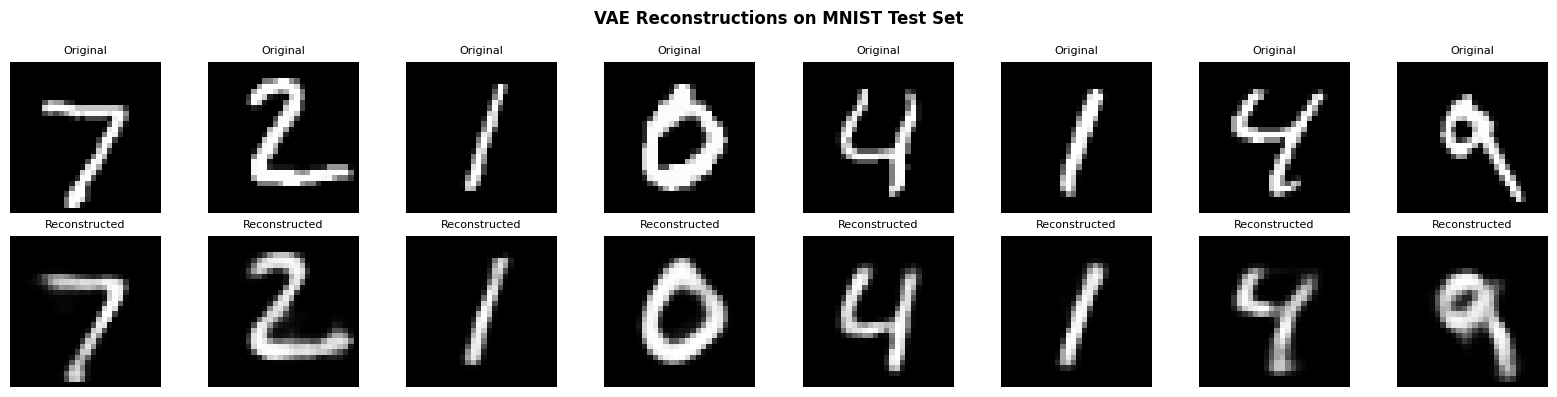

In [6]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    x_sample, _ = next(iter(test_loader))
    x_sample    = x_sample[:8].to(DEVICE)
    x_recon, _, _ = model(x_sample)

# Reshape back to 28×28 for display
originals     = x_sample.cpu().view(-1, 28, 28)
reconstructed = x_recon.cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(originals[i],     cmap='gray')
    axes[0, i].set_title('Original',    fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(reconstructed[i], cmap='gray')
    axes[1, i].set_title('Reconstructed', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('VAE Reconstructions on MNIST Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()